# Project: Wild Watch Pk
### Pakistan Wildlife Extinction Risk Analyzer

### Summary:
* Pakistan is home to some of the most extraordinary wildlife on earth. Snow Leopard, Markhor, Indus Dolphin, Marco Polo Sheep etc animals that exist nowhere else in the world the way they exist here. But right now, they are disappearing. And the tragedy is not just that they are dying. The tragedy is that no one is measuring it properly.
* Wildlife departments across Pakistan still rely on manual field surveys, outdated census reports, and institutional guesswork. There is no data driven system that continuously monitors species populations, detects warning signs early, and tells decision makers exactly where to act before it is too late.
* This project is my attempt to change that.
* WildWatch PK is a complete end to end Machine Learning pipeline built on real verified biodiversity data sourced from Kaggle, covering thousands of wildlife observations recorded across Pakistan over decades. The project moves through every stage of a professional data science workflow including raw data collection, deep preprocessing and cleaning, exploratory data analysis, feature engineering, trend modeling, and extinction risk prediction at the species and region level.
* What this project actually does is identify which Pakistani species have the sharpest population decline, map which geographic regions are becoming wildlife dead zones, build a predictive model that scores extinction risk before it becomes irreversible, and visualize everything in a way that a conservationist, a policymaker, or a journalist can immediately understand and act on.
* The scope of this project goes beyond a semester assignment. The same pipeline can be scaled, updated with fresh observation data every month, and deployed as a monitoring tool for organizations like WWF Pakistan, IUCN, and provincial Wildlife Departments who currently have no such system available to them.
* #### I built this as a student. But I built it like someone who knows that the difference between data and action is just the right model, the right visualization, and the will to make something that actually matters.

## Step 1: Import Libraries

In [3]:
import pandas as pd                    # For Data Manipulation & Data Analysis
import matplotlib.pyplot as plt        # For Data Visualization
import seaborn as sns                  # For Advance Data Visualization
import numpy as np                     # For Numerical Calculation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

## Step 2: Load Dataset
 * ##### Dataset = Custom built dataset covering Pakistan's wildlife population. Data references sourced from Animalia. Link: https://animalia.bio/pakistan-animals#google_vignette

In [4]:
# Load Dataset & show first 5 rows.
df =pd.read_csv(r"D:\4th Semester\Machine Learning by Sir  Abdul Aziz\Project WildWatch Pk\animal_dataset.csv")
df.head()

,Animal ID,Name,Kingdom,Phylum,Subphylum,Class,Order,Infraorder,Family,Genus,...,Top speed km/h,Min-Weight (kg),Max-Weight (kg),Min-Length (M),Max-Length (M),Min-Height (cm),Max-Height (cm),Min-Wingspan (cm),Max-Wingspan (cm),Current_population
0,1,Blue Whale,Animalia,Chordata,Vertebrata,Mammalia,Artiodactyla,Cetacea,Balaenopteridae,Balaenoptera,...,20.0,90718.50,145150.00,25.00,30.0,NaN,NaN,NaN,NaN,25000.0
1,2,Killer Whale,Animalia,Chordata,Vertebrata,Mammalia,Artiodactyla,Cetacea,Delphinidae,Orcinus,...,45.0,2721.55,5443.11,6.00,9.0,NaN,NaN,NaN,NaN,50000.0
2,3,Grey Wolf,Animalia,Chordata,Vertebrata,Mammalia,Carnivora,Caniformia,Canidae,Canis,...,65.0,16.00,60.00,1.05,1.6,80.0,85.0,NaN,NaN,3000000.0
3,4,Brown Bear,Animalia,Chordata,Vertebrata,Mammalia,Carnivora,Caniformia,Ursidae,Ursus,...,56.0,100.00,635.00,1.40,2.8,70.0,153.0,NaN,NaN,200000.0
4,5,Leopard,Animalia,Chordata,Vertebrata,Mammalia,Carnivora,Feliformia,Felidae,Panthera,...,58.0,28.00,90.00,0.90,1.9,57.0,70.0,NaN,NaN,100000.0


In [5]:
# Total Number of Rows & columns in Dataset
df.shape

(42, 25)

In [6]:
# Information of Dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Animal ID            42 non-null     int64  
 1   Name                 42 non-null     str    
 2   Kingdom              42 non-null     str    
 3   Phylum               42 non-null     str    
 4   Subphylum            27 non-null     str    
 5   Class                42 non-null     str    
 6   Order                42 non-null     str    
 7   Infraorder           22 non-null     str    
 8   Family               42 non-null     str    
 9   Genus                42 non-null     str    
 10  Species              42 non-null     str    
 11  Min-Population size  26 non-null     str    
 12  Max-Population size  25 non-null     str    
 13  Min-Life Span        41 non-null     float64
 14  Max-Life Span        41 non-null     float64
 15  Top speed km/h       30 non-null     float64
 16  Min

## Step 3: Data Peprocessing

In [7]:
# Total Number of Rows & Columns of Final Dataset.
df.shape

(42, 25)

In [8]:
# Information of Final Dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Animal ID            42 non-null     int64  
 1   Name                 42 non-null     str    
 2   Kingdom              42 non-null     str    
 3   Phylum               42 non-null     str    
 4   Subphylum            27 non-null     str    
 5   Class                42 non-null     str    
 6   Order                42 non-null     str    
 7   Infraorder           22 non-null     str    
 8   Family               42 non-null     str    
 9   Genus                42 non-null     str    
 10  Species              42 non-null     str    
 11  Min-Population size  26 non-null     str    
 12  Max-Population size  25 non-null     str    
 13  Min-Life Span        41 non-null     float64
 14  Max-Life Span        41 non-null     float64
 15  Top speed km/h       30 non-null     float64
 16  Min

In [9]:
# Now,Checking Total Number of  Duplicated rows
df.duplicated().sum()

np.int64(0)

In [10]:
# Checking the Missing values in each row
df.isnull().sum()

Animal ID               0
Name                    0
Kingdom                 0
Phylum                  0
Subphylum              15
Class                   0
Order                   0
Infraorder             20
Family                  0
Genus                   0
Species                 0
Min-Population size    16
Max-Population size    17
Min-Life Span           1
Max-Life Span           1
Top speed km/h         12
Min-Weight (kg)         3
Max-Weight (kg)         3
Min-Length (M)          0
Max-Length (M)          0
Min-Height (cm)        30
Max-Height (cm)        30
Min-Wingspan (cm)      27
Max-Wingspan (cm)      27
Current_population     22
dtype: int64

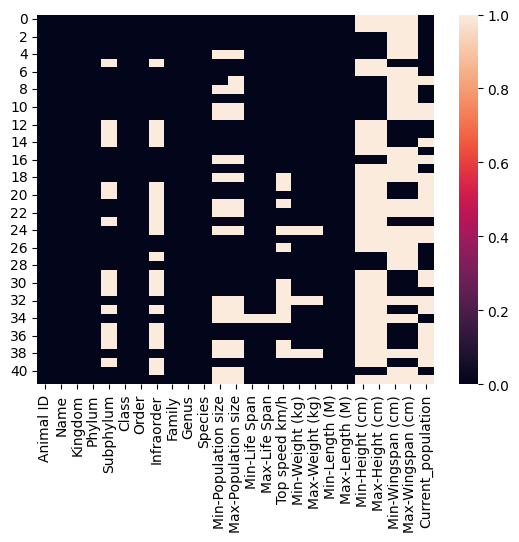

In [11]:
# Graphical Representation of Missing values by Heatmap
sns.heatmap(df.isnull())
plt.show()

In [12]:
# Checking Percentage of Missing value in whole Dataset
(df.isnull().sum().sum()/(df.shape[0]*df.shape[1]))*100

np.float64(21.333333333333336)

## Categorical Filling

In [13]:
for i in df.select_dtypes(include='str').columns:
   df[i]=df[i].fillna(df[i].mode()[0])

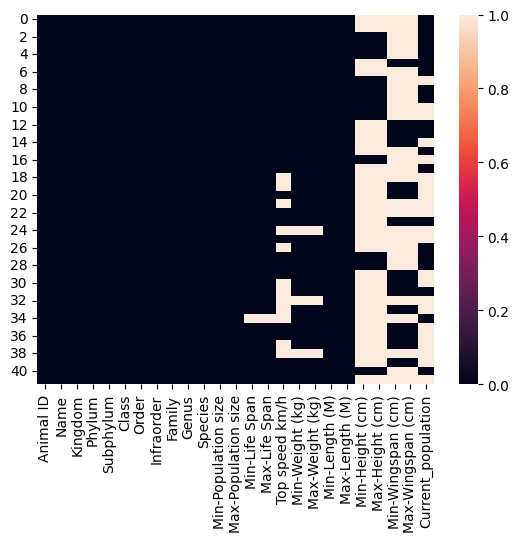

In [14]:
#Graphical Representation of Null values in Dataset
sns.heatmap(df.isnull())
plt.show()

## Numerical Filling

In [15]:
for i in df.select_dtypes(include='float64').columns:
   df[i]=df[i].fillna(df[i].mean())

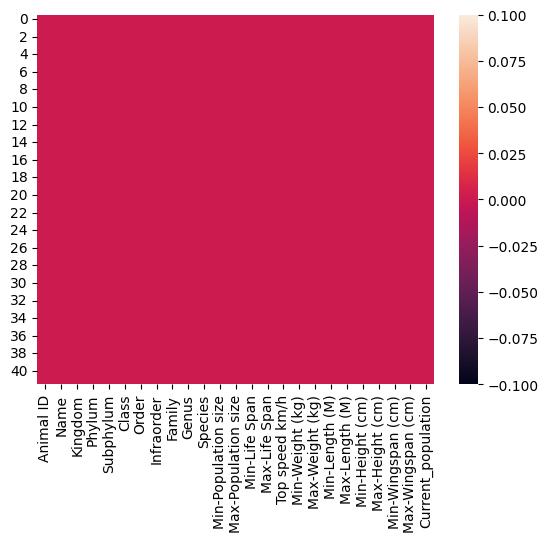

In [16]:
#Graphical Representation of Null values in Dataset
sns.heatmap(df.isnull())
plt.show()

In [17]:
df.isnull().sum().sum()

np.int64(0)

## Drop Unnecessary Columns

In [18]:
df.head(8)

,Animal ID,Name,Kingdom,Phylum,Subphylum,Class,Order,Infraorder,Family,Genus,...,Top speed km/h,Min-Weight (kg),Max-Weight (kg),Min-Length (M),Max-Length (M),Min-Height (cm),Max-Height (cm),Min-Wingspan (cm),Max-Wingspan (cm),Current_population
0,1,Blue Whale,Animalia,Chordata,Vertebrata,Mammalia,Artiodactyla,Cetacea,Balaenopteridae,Balaenoptera,...,20.0,90718.50,145150.00,25.00,30.00,61.25,87.166667,95.6,128.166667,25000.0
1,2,Killer Whale,Animalia,Chordata,Vertebrata,Mammalia,Artiodactyla,Cetacea,Delphinidae,Orcinus,...,45.0,2721.55,5443.11,6.00,9.00,61.25,87.166667,95.6,128.166667,50000.0
2,3,Grey Wolf,Animalia,Chordata,Vertebrata,Mammalia,Carnivora,Caniformia,Canidae,Canis,...,65.0,16.00,60.00,1.05,1.60,80.00,85.000000,95.6,128.166667,3000000.0
3,4,Brown Bear,Animalia,Chordata,Vertebrata,Mammalia,Carnivora,Caniformia,Ursidae,Ursus,...,56.0,100.00,635.00,1.40,2.80,70.00,153.000000,95.6,128.166667,200000.0
4,5,Leopard,Animalia,Chordata,Vertebrata,Mammalia,Carnivora,Feliformia,Felidae,Panthera,...,58.0,28.00,90.00,0.90,1.90,57.00,70.000000,95.6,128.166667,100000.0
5,6,Peregrine Falcon,Animalia,Chordata,Vertebrata,Aves,Falconiformes,Feliformia,Falconidae,Falco,...,389.0,330.00,1500.00,0.34,0.58,61.25,87.166667,74.0,120.000000,100000.0
6,7,Sperm Whale,Animalia,Chordata,Vertebrata,Mammalia,Artiodactyla,Cetacea,Physeteridae,Physeter,...,45.0,10886.20,37013.14,11.00,18.00,61.25,87.166667,95.6,128.166667,100000.0
7,8,Honey Badger,Animalia,Chordata,Vertebrata,Mammalia,Carnivora,Caniformia,Mustelidae,Mellivora,...,30.0,5.00,16.00,0.77,0.77,23.00,28.000000,95.6,128.166667,220250.0


In [19]:
df.drop(columns=['Animal ID','Kingdom','Phylum','Subphylum','Class'],inplace=True)

In [20]:
df.head()

,Name,Order,Infraorder,Family,Genus,Species,Min-Population size,Max-Population size,Min-Life Span,Max-Life Span,Top speed km/h,Min-Weight (kg),Max-Weight (kg),Min-Length (M),Max-Length (M),Min-Height (cm),Max-Height (cm),Min-Wingspan (cm),Max-Wingspan (cm),Current_population
0,Blue Whale,Artiodactyla,Cetacea,Balaenopteridae,Balaenoptera,Balaenoptera musculus,"5,000","15,000",80.0,90.0,20.0,90718.50,145150.00,25.00,30.0,61.25,87.166667,95.6,128.166667,25000.0
1,Killer Whale,Artiodactyla,Cetacea,Delphinidae,Orcinus,Orcinus orca,"50,000","50,000",30.0,100.0,45.0,2721.55,5443.11,6.00,9.0,61.25,87.166667,95.6,128.166667,50000.0
2,Grey Wolf,Carnivora,Caniformia,Canidae,Canis,Canis lupus,"400,000","400,000",10.0,20.0,65.0,16.00,60.00,1.05,1.6,80.00,85.000000,95.6,128.166667,3000000.0
3,Brown Bear,Carnivora,Caniformia,Ursidae,Ursus,Ursus arctos,"200,000","200,000",20.0,50.0,56.0,100.00,635.00,1.40,2.8,70.00,153.000000,95.6,128.166667,200000.0
4,Leopard,Carnivora,Feliformia,Felidae,Panthera,Panthera pardus,"100,000","500,000",10.0,20.0,58.0,28.00,90.00,0.90,1.9,57.00,70.000000,95.6,128.166667,100000.0


In [21]:
# Again Check rows & columns
df.shape

(42, 20)

In [22]:
df['Name'].unique()

<ArrowStringArray>
[          ' Blue Whale',         ' Killer Whale',            ' Grey Wolf',
           ' Brown Bear',              ' Leopard',     ' Peregrine Falcon',
          ' Sperm Whale',         ' Honey Badger',         ' Bengal Tiger',
         ' Snow Leopard',            ' Wild Boar',               'Red Fox',
         ' Golden Eagle',               ' Osprey',              ' Mallard',
        'Humpback Whale',               'Caracal',                'Mugger',
                'Ermine',              'Barn Owl',        'Indian Peafowl',
      'Asian Palm Civet',           'House Mouse',             'Snowy Owl',
    'Common House Gecko',      'Green Sea Turtle',          'Pallas's Cat',
               'Markhor',         'Eurasian Lynx',        'Common Buzzard',
         'Common Cuckoo',       'Bearded Vulture',       'Russell's Viper',
        'Red Junglefowl', 'Loggerhead sea turtle',          'Barn Swallow',
    'Eurasian Eagle-Owl',  'Rose-Ringed Parakeet',          'Indian C

### Outliers

In [23]:
df['Min-Population size'].unique()

<ArrowStringArray>
[      '5,000',      '50,000',     '400,000',     '200,000',     '100,000',
           ' ',       '2,710',      '85,000',  '19,000,000',      '60,000',
       '5,700',   '4,000,000',      '28,000',      '58,000',       '5,754',
      '70,000',   '2,100,000',  '40,000,000',       '2,000', '290,000,000',
   '260000000']
Length: 21, dtype: str

In [24]:
# Converting str to int
df['Min-Population size'] = df['Min-Population size'].str.replace(',','')
df['Min-Population size'] = df['Min-Population size'].str.replace(' ','85000')
df['Max-Population size'] = df['Max-Population size'].str.replace(',','')

df['Min-Population size']=df['Min-Population size'].astype("int64")
df['Max-Population size']=df['Max-Population size'].astype("int64")

In [25]:
df.describe()

,Min-Population size,Max-Population size,Min-Life Span,Max-Life Span,Top speed km/h,Min-Weight (kg),Max-Weight (kg),Min-Length (M),Max-Length (M),Min-Height (cm),Max-Height (cm),Min-Wingspan (cm),Max-Wingspan (cm),Current_population
count,4.200000e+01,4.200000e+01,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,4.200000e+01
mean,1.472243e+07,2.062212e+07,20.780488,33.317073,67.600000,3323.555795,5655.686385,2.180000,2.928690,61.250000,87.166667,95.600000,128.166667,2.202500e+05
std,5.938267e+07,8.453541e+07,23.960854,24.970899,58.508536,14348.519418,23146.581135,4.484519,5.682792,11.512718,20.477035,32.447932,42.440154,4.480375e+05
min,2.000000e+03,3.386000e+03,1.000000,5.000000,3.000000,0.010000,0.022000,0.075000,0.100000,23.000000,28.000000,32.000000,34.500000,2.000000e+02
25%,8.500000e+04,9.250000e+04,7.000000,17.750000,45.000000,0.975000,2.250000,0.427500,0.605000,61.250000,87.166667,95.600000,128.166667,6.350000e+04
50%,1.000000e+05,5.000000e+05,12.500000,25.000000,67.600000,8.000000,24.000000,0.760000,1.070000,61.250000,87.166667,95.600000,128.166667,2.202500e+05
75%,1.000000e+05,5.000000e+05,20.945122,38.750000,72.400000,100.000000,521.250000,1.380000,1.975000,61.250000,87.166667,95.600000,128.166667,2.202500e+05
max,2.900000e+08,4.870000e+08,100.000000,100.000000,389.000000,90718.500000,145150.000000,25.000000,30.000000,100.000000,153.000000,230.000000,280.000000,3.000000e+06


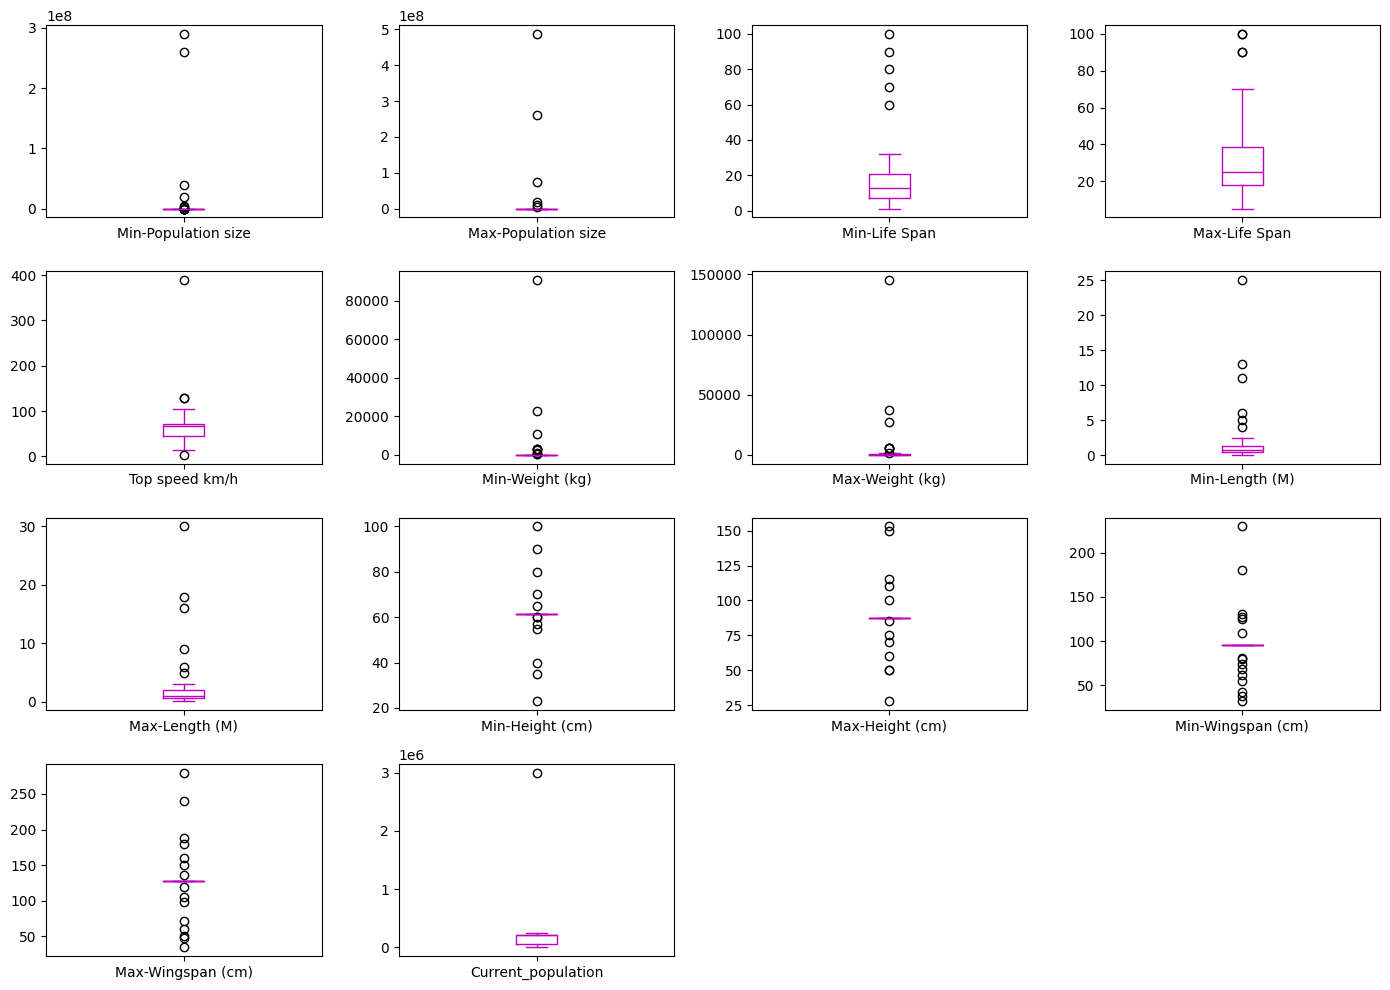

In [26]:
# Check outliers by boxplot
df.plot(kind='box',subplots=True,layout=(4,4),figsize=(14,10),color='m')
plt.tight_layout()
plt.show()

#### "These outliers are not data errors, they are real ecological observations. Since the goal is to identify endangered species, removing them would remove the most important information from the dataset."

### Label Encoding

In [27]:
# For later use
animal_names = df['Name'].copy()

In [28]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in df.select_dtypes(include='str').columns:
    df[i]=le.fit_transform(df[i])

In [29]:
# Check Dataset Encoding
df.head()

,Name,Order,Infraorder,Family,Genus,Species,Min-Population size,Max-Population size,Min-Life Span,Max-Life Span,Top speed km/h,Min-Weight (kg),Max-Weight (kg),Min-Length (M),Max-Length (M),Min-Height (cm),Max-Height (cm),Min-Wingspan (cm),Max-Wingspan (cm),Current_population
0,1,8,2,2,2,2,5000,15000,80.0,90.0,20.0,90718.50,145150.00,25.00,30.0,61.25,87.166667,95.6,128.166667,25000.0
1,6,8,2,9,26,27,50000,50000,30.0,100.0,45.0,2721.55,5443.11,6.00,9.0,61.25,87.166667,95.6,128.166667,50000.0
2,4,9,1,4,6,7,400000,400000,10.0,20.0,65.0,16.00,60.00,1.05,1.6,80.00,85.000000,95.6,128.166667,3000000.0
3,2,9,1,24,38,40,200000,200000,20.0,50.0,56.0,100.00,635.00,1.40,2.8,70.00,153.000000,95.6,128.166667,200000.0
4,7,9,4,12,29,30,100000,500000,10.0,20.0,58.0,28.00,90.00,0.90,1.9,57.00,70.000000,95.6,128.166667,100000.0


### ADD Target Column "Extinction Risk" in Dataset

In [30]:
df['Extinction_Risk'] = 0

for i in df.index:
    if df.loc[i, 'Current_population'] < 10000:
        df.loc[i, 'Extinction_Risk'] = 2              # High Risk
    elif df.loc[i, 'Current_population'] < 100000:
        df.loc[i, 'Extinction_Risk'] = 1              # Medium Risk
    else:
        df.loc[i, 'Extinction_Risk'] = 0              # Low Risk

In [31]:
df.head()

,Name,Order,Infraorder,Family,Genus,Species,Min-Population size,Max-Population size,Min-Life Span,Max-Life Span,...,Min-Weight (kg),Max-Weight (kg),Min-Length (M),Max-Length (M),Min-Height (cm),Max-Height (cm),Min-Wingspan (cm),Max-Wingspan (cm),Current_population,Extinction_Risk
0,1,8,2,2,2,2,5000,15000,80.0,90.0,...,90718.50,145150.00,25.00,30.0,61.25,87.166667,95.6,128.166667,25000.0,1
1,6,8,2,9,26,27,50000,50000,30.0,100.0,...,2721.55,5443.11,6.00,9.0,61.25,87.166667,95.6,128.166667,50000.0,1
2,4,9,1,4,6,7,400000,400000,10.0,20.0,...,16.00,60.00,1.05,1.6,80.00,85.000000,95.6,128.166667,3000000.0,0
3,2,9,1,24,38,40,200000,200000,20.0,50.0,...,100.00,635.00,1.40,2.8,70.00,153.000000,95.6,128.166667,200000.0,0
4,7,9,4,12,29,30,100000,500000,10.0,20.0,...,28.00,90.00,0.90,1.9,57.00,70.000000,95.6,128.166667,100000.0,0


In [32]:
df['Extinction_Risk'].value_counts()

Extinction_Risk
0    30
1     8
2     4
Name: count, dtype: int64

### Normalization

In [33]:
# Converting all values into  0/1 form.
from sklearn.preprocessing import MinMaxScaler
m = MinMaxScaler()
for i in df.drop(columns='Extinction_Risk').columns:
    df[i]=m.fit_transform(df[[i]])

In [34]:
df.head(9)

,Name,Order,Infraorder,Family,Genus,Species,Min-Population size,Max-Population size,Min-Life Span,Max-Life Span,...,Min-Weight (kg),Max-Weight (kg),Min-Length (M),Max-Length (M),Min-Height (cm),Max-Height (cm),Min-Wingspan (cm),Max-Wingspan (cm),Current_population,Extinction_Risk
0,0.024390,0.470588,0.4,0.076923,0.051282,0.048780,0.000010,0.000024,0.797980,0.894737,...,1.000000,1.000000,1.000000,1.000000,0.496753,0.473333,0.321212,0.381534,0.008267,1
1,0.146341,0.470588,0.4,0.346154,0.666667,0.658537,0.000166,0.000096,0.292929,1.000000,...,0.030000,0.037500,0.237713,0.297659,0.496753,0.473333,0.321212,0.381534,0.016601,1
2,0.097561,0.529412,0.2,0.153846,0.153846,0.170732,0.001372,0.000814,0.090909,0.157895,...,0.000176,0.000413,0.039117,0.050167,0.740260,0.456000,0.321212,0.381534,1.000000,0
3,0.048780,0.529412,0.2,0.923077,0.974359,0.975610,0.000683,0.000404,0.191919,0.473684,...,0.001102,0.004375,0.053159,0.090301,0.610390,1.000000,0.321212,0.381534,0.066604,0
4,0.170732,0.529412,0.8,0.461538,0.743590,0.731707,0.000338,0.001020,0.090909,0.157895,...,0.000309,0.000620,0.033099,0.060201,0.441558,0.336000,0.321212,0.381534,0.033269,0
5,0.243902,0.647059,0.8,0.423077,0.384615,0.390244,0.000338,0.001020,0.181818,0.210526,...,0.003638,0.010334,0.010632,0.016054,0.496753,0.473333,0.212121,0.348269,0.033269,0
6,0.292683,0.470588,0.4,0.730769,0.846154,0.829268,0.000338,0.000732,0.696970,0.684211,...,0.120000,0.254999,0.438315,0.598662,0.496753,0.473333,0.321212,0.381534,0.033269,0
7,0.121951,0.529412,0.2,0.615385,0.564103,0.560976,0.000286,0.001020,0.060606,0.221053,...,0.000055,0.000110,0.027884,0.022408,0.000000,0.000000,0.321212,0.381534,0.073355,0
8,0.000000,0.529412,0.8,0.461538,0.769231,0.756098,0.000338,0.001020,0.090909,0.105263,...,0.000882,0.001791,0.099298,0.100669,0.870130,0.656000,0.321212,0.381534,0.001700,2


In [35]:
df.shape

(42, 21)

### Correlation by Heatmap

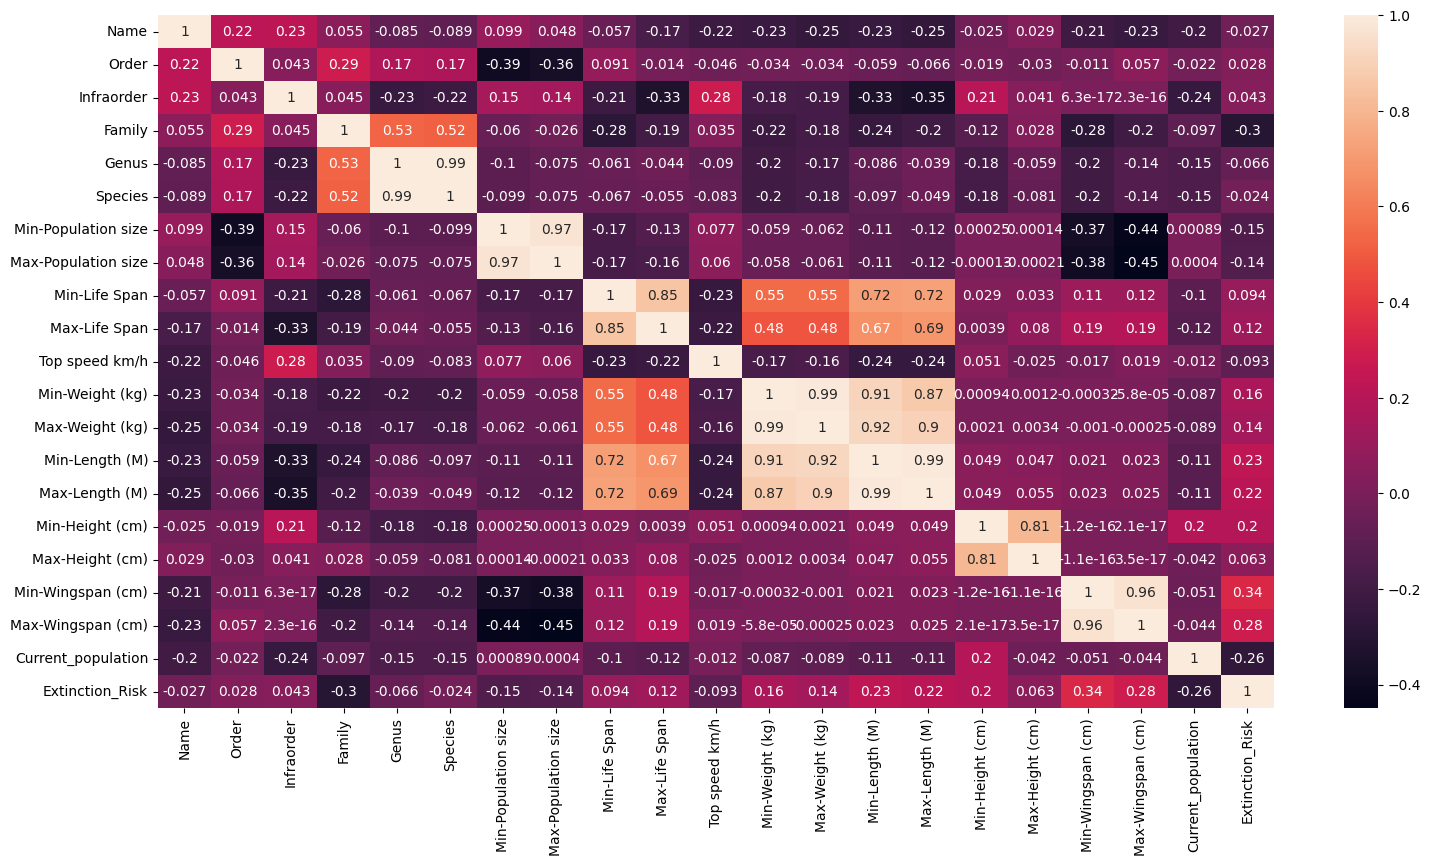

In [36]:
plt.figure(figsize=(18,9))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

### Train Test split

In [37]:
# Take Only Necessary Features
X = df[['Min-Population size','Max-Population size','Min-Life Span','Max-Life Span','Min-Length (M)','Min-Wingspan (cm)','Current_population']]
y = df['Extinction_Risk']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

### Apply Model

In [38]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Prediction

In [39]:
pred = rf.predict(X_test)

### Accuracy

In [40]:
acc = accuracy_score(y_test,pred)
print("Accuracy:",acc*100)

Accuracy: 88.88888888888889


### Classification Report

In [41]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      0.50      0.67         2
           2       0.50      1.00      0.67         1

    accuracy                           0.89         9
   macro avg       0.83      0.83      0.78         9
weighted avg       0.94      0.89      0.89         9



### Confusion Matrix

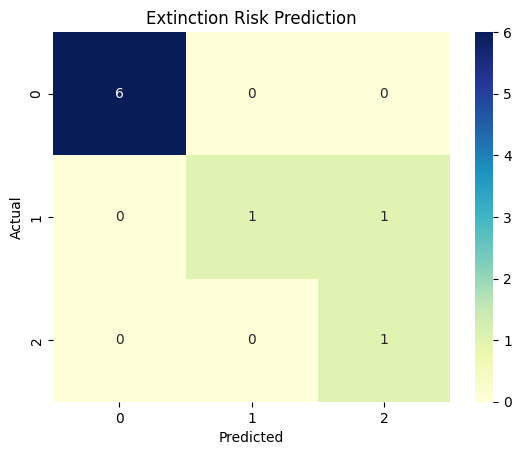

In [42]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,pred)
sns.heatmap(cm,annot=True,cmap='YlGnBu',fmt='d')
plt.title("Extinction Risk Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Random Forest Visualization

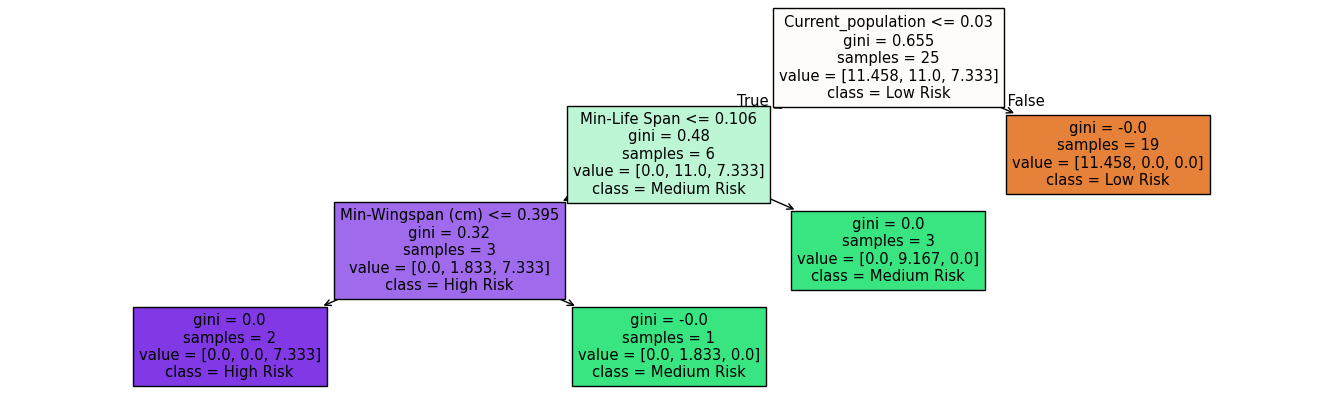

In [43]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(17,5))
plot_tree(rf.estimators_[0],feature_names=X.columns,class_names=['Low Risk','Medium Risk','High Risk'],filled=True)
plt.show()

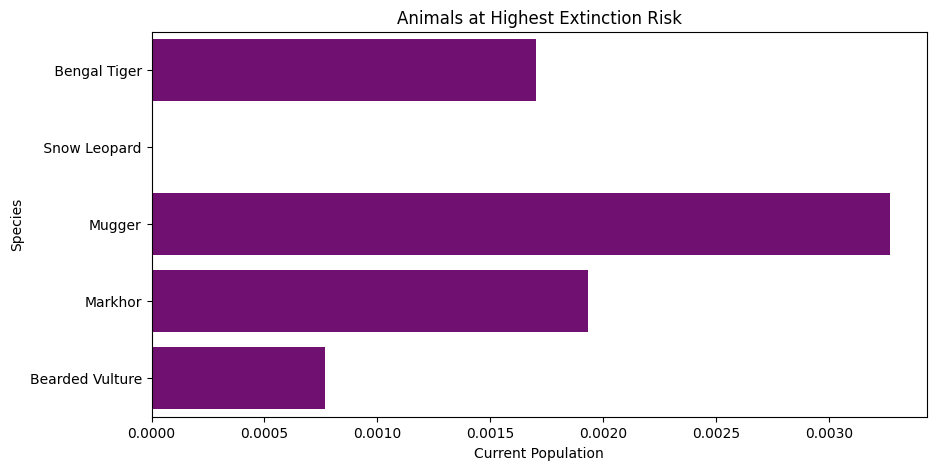

In [44]:
# graph
df['Animal_Name'] = animal_names
df['prediction'] = rf.predict(X)
high_risk = df[df['prediction'] == 2]
plt.figure(figsize=(10,5))
sns.barplot(x='Current_population',y='Animal_Name',data=high_risk,color='purple')
plt.title("Animals at Highest Extinction Risk")
plt.xlabel("Current Population")
plt.ylabel("Species")
plt.show()

### Visulaization of Feature Importance

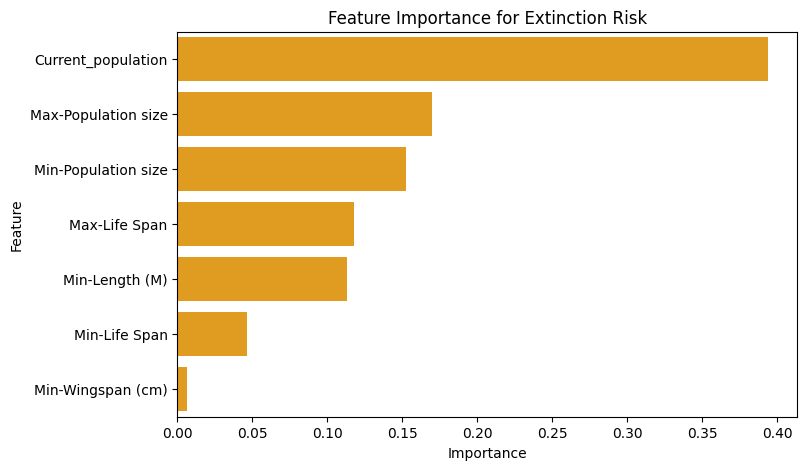

In [45]:
importance = pd.DataFrame({'Feature':X.columns,'Importance':rf.feature_importances_})
importance = importance.sort_values(by='Importance',ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=importance,x='Importance',y='Feature',color='orange')
plt.title("Feature Importance for Extinction Risk")
plt.show()

### New Animal Test

In [46]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [47]:
new_animal = pd.DataFrame ({ 'Min-Population size':[1000],'Max-Population size':[10000],'Min-Life Span':[5],'Max-Life Span':[15],
                             'Min-Length (M)':[12],'Min-Wingspan (cm)':[120],'Current Population':[500]})
new_animal_scaled = scaler.fit_transform(new_animal)
prediction = rf.predict(new_animal_scaled)
print(prediction)

[2]


C:\Users\Computer.com\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
